In [50]:
# Standard library
import os
import json
import shutil
import pickle
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bars
from tqdm import tqdm
from tqdm.auto import tqdm

# Computer vision
import cv2
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

# Torchvision
import torchvision
from torchvision import transforms
from torchvision import models

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

# Scientific computing
from scipy.spatial.distance import euclidean

# MediaPipe
import mediapipe as mp

In [51]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

with open(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "folds.json"
) as f:
    folds = json.load(f)

print("Number of folds:", len(folds))

Number of folds: 5


In [52]:
TEST_SUBJECTS = ["01", "06", "11", "16", "21", "26", "31", "36", "41"]
windows_df = pd.read_csv(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "windows.csv"
)

windows_df["subject"] = (
    windows_df["subject"]
    .astype(str)
    .str.zfill(2)
)

test_df = windows_df[
    windows_df["subject"].isin(TEST_SUBJECTS)
]

print("Test subjects:")
print(sorted(test_df["subject"].unique()))
print("Number of subjects:",
      len(test_df["subject"].unique()))
print("Number of windows:",
      len(test_df))

Test subjects:
['01', '06', '11', '16', '21', '26', '31', '36', '41']
Number of subjects: 9
Number of windows: 1632


In [53]:
all_dev = set()

for fold in folds:
    all_dev.update(fold["train_subjects"])
    all_dev.update(fold["val_subjects"])

print("Development subjects:", len(all_dev))
print("Overlap with test subjects:",
      sorted(all_dev & set(TEST_SUBJECTS)))

assert len(all_dev) == 38
assert len(all_dev & set(TEST_SUBJECTS)) == 0

print("✅ Test subjects are completely excluded from development folds.")

Development subjects: 38
Overlap with test subjects: []
✅ Test subjects are completely excluded from development folds.


In [54]:
for p in (PROJECT_ROOT / "processed" / "UTA" / "windows").iterdir():
    print(p)

In [55]:
from pathlib import Path

DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

for p in DATA_ROOT.iterdir():
    print(p.name)


print(len(list(DATA_ROOT.iterdir())))
print(sorted([p.name for p in DATA_ROOT.iterdir()])[:15])

Fold1_part1
Fold1_part2
Fold2_part1
Fold2_part2
Fold3_part1
Fold3_part2
Fold4_part1
Fold4_part2
8
['Fold1_part1', 'Fold1_part2', 'Fold2_part1', 'Fold2_part2', 'Fold3_part1', 'Fold3_part2', 'Fold4_part1', 'Fold4_part2']


In [56]:
from pathlib import Path

for p in (PROJECT_ROOT / "datasets").iterdir():
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\MENDELEY
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\NTHU
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA


In [57]:
for fold_dir in DATA_ROOT.iterdir():
    nested = fold_dir / fold_dir.name
    print(nested)
    print(
        sorted([
            p.name for p in nested.iterdir()
            if p.is_dir()
        ])[:10]
    )
    print()

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1
['01', '02', '03', '04', '05', '06']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2
['07', '08', '09', '10', '11', '12']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part1\Fold2_part1
['13', '14', '15', '16', '17', '18']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part2\Fold2_part2
['19', '20', '21', '22', '23', '24']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part1\Fold3_part1
['25', '26', '27', '28', '29', '30']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2
['31', '32', '33', '34', '35', '36']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part1\Fold4_part1
['37', '38', '39', '40', '41']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part2\Fold4_part2
['42', '43', '44', '45', '46', '47',

In [58]:
subject_paths = {}

for subject in TEST_SUBJECTS:

    for fold_dir in DATA_ROOT.iterdir():

        nested = fold_dir / fold_dir.name
        path = nested / subject

        if path.exists():
            subject_paths[subject] = path
            break

for s, p in subject_paths.items():
    print(s, "->", p)

01 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01
06 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\06
11 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2\11
16 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part1\Fold2_part1\16
21 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part2\Fold2_part2\21
26 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part1\Fold3_part1\26
31 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2\31
36 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2\36
41 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part1\Fold4_part1\41


In [59]:
subject = "01"
path = subject_paths[subject]

for p in path.rglob("*"):
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\0.mov
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\10.MOV
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\5.mov


In [60]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import euclidean
from tqdm import tqdm

In [61]:
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

TEST_SUBJECTS = [
    "01","06","11","16","21",
    "26","31","36","41"
]

In [62]:
windows_df = pd.read_csv(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "windows.csv"
)

windows_df["subject"] = (
    windows_df["subject"]
    .astype(str)
    .str.zfill(2)
)

test_df = windows_df[
    windows_df["subject"].isin(TEST_SUBJECTS)
]

print("Test subjects:", sorted(test_df["subject"].unique()))
print("Number of test subjects:", len(test_df["subject"].unique()))
print("Number of test windows:", len(test_df))

Test subjects: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
Number of test subjects: 9
Number of test windows: 1632


In [63]:
subject_paths = {}

for subject in TEST_SUBJECTS:
    for fold_dir in DATA_ROOT.iterdir():

        nested = fold_dir / fold_dir.name
        path = nested / subject

        if path.exists():
            subject_paths[subject] = path
            break

subject_paths

{'01': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part1/Fold1_part1/01'),
 '06': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part1/Fold1_part1/06'),
 '11': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part2/Fold1_part2/11'),
 '16': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold2_part1/Fold2_part1/16'),
 '21': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold2_part2/Fold2_part2/21'),
 '26': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part1/Fold3_part1/26'),
 '31': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part2/Fold3_part2/31'),
 '36': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part2/Fold3_part2/36'),
 '41': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold

In [64]:
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [65]:
def eye_aspect_ratio(eye):
    A = euclidean(eye[1], eye[5])
    B = euclidean(eye[2], eye[4])
    C = euclidean(eye[0], eye[3])

    if C == 0:
        return np.nan

    return (A + B) / (2.0 * C)

In [66]:
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

In [67]:
from tqdm.auto import tqdm

ear_records = []

for subject, path in subject_paths.items():

    print(f"\n{'='*60}")
    print(f"Subject {subject}")
    print(f"{'='*60}")

    # Automatically find 0, 5 and 10 videos
    videos = []

    for stem in ["0", "5", "10"]:
        matches = list(path.glob(f"{stem}.*"))

        if len(matches) == 0:
            print(f"❌ Could not find video {stem} for subject {subject}")
            continue

        videos.append(matches[0])

    labels = {
        "0": "Alert",
        "5": "Low Vigilant",
        "10": "Drowsy"
    }

    for video_path in videos:

        print(f"\nProcessing {video_path.name}")

        cap = cv2.VideoCapture(str(video_path))

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        for frame_idx in tqdm(
            range(total_frames),
            desc=f"{subject}-{video_path.name}",
            leave=True
        ):

            ret, frame = cap.read()

            if not ret:
                break

            rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            result = face_mesh.process(rgb)

            if result.multi_face_landmarks:

                landmarks = (
                    result
                    .multi_face_landmarks[0]
                    .landmark
                )

                h, w = frame.shape[:2]

                left_eye = []
                right_eye = []

                for idx in LEFT_EYE:
                    lm = landmarks[idx]
                    left_eye.append(
                        (lm.x * w, lm.y * h)
                    )

                for idx in RIGHT_EYE:
                    lm = landmarks[idx]
                    right_eye.append(
                        (lm.x * w, lm.y * h)
                    )

                left_ear = eye_aspect_ratio(left_eye)
                right_ear = eye_aspect_ratio(right_eye)

                ear = np.mean(
                    [left_ear, right_ear]
                )

            else:
                ear = np.nan

            ear_records.append({
                "subject": subject,
                "video": video_path.name,
                "label": labels[video_path.stem],
                "frame": frame_idx,
                "ear": ear
            })

        cap.release()

        print(
            f"✅ Finished {video_path.name} "
            f"({total_frames:,} frames)"
        )

print("\n✅ EAR extraction complete.")
print(f"Total records: {len(ear_records):,}")


Subject 01

Processing 0.mov


01-0.mov:   0%|          | 0/18053 [00:00<?, ?it/s]

c:\Users\clark\OneDrive\Desktop\drowsiness_project\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Finished 0.mov (18,053 frames)

Processing 5.mov


01-5.mov:   0%|          | 0/17969 [00:00<?, ?it/s]

...

✅ Finished 0.MP4 (18,840 frames)

Processing 5.mp4


41-5.mp4:   0%|          | 0/10777 [00:00<?, ?it/s]

✅ Finished 5.mp4 (10,777 frames)

Processing 10.MOV


41-10.MOV:   0%|          | 0/28325 [00:00<?, ?it/s]

✅ Finished 10.MOV (28,325 frames)

✅ EAR extraction complete.
Total records: 454,729


In [68]:
ear_df = pd.DataFrame(ear_records)

ear_df.to_csv(
    PROJECT_ROOT / "ear_per_frame.csv",
    index=False
)

ear_df.head()

,subject,video,label,frame,ear
0,01,0.mov,Alert,0,0.276090
1,01,0.mov,Alert,1,0.260982
2,01,0.mov,Alert,2,0.262441
3,01,0.mov,Alert,3,0.260374
4,01,0.mov,Alert,4,0.264320


In [71]:
TEST_SUBJECTS = [
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
]

ear_df["subject"] = (
    ear_df["subject"]
    .astype(str)
    .str.zfill(2)
)

ear_df = ear_df[
    ear_df["subject"].isin(TEST_SUBJECTS)
].copy()

print(
    sorted(
        ear_df["subject"].unique()
    )
)

['01', '06', '11', '16', '21', '26', '31', '36', '41']


In [72]:
EAR_THRESHOLD = 0.20
CONSEC_FRAMES = 20

predictions = []

for (subject, video), group in ear_df.groupby(
    ["subject", "video"]
):

    counter = 0

    for _, row in group.iterrows():

        ear = row["ear"]

        if np.isnan(ear):
            pred = "Alert"

        else:
            if ear < EAR_THRESHOLD:
                counter += 1
            else:
                counter = 0

            if counter >= CONSEC_FRAMES:
                pred = "Drowsy"
            else:
                pred = "Alert"

        predictions.append(pred)

ear_df["ear_prediction"] = predictions

low_df = ear_df[
    ear_df["label"] == "Low Vigilant"
]

print(
    low_df["ear_prediction"]
    .value_counts(normalize=True)
    * 100
)

ear_df.to_csv(
    PROJECT_ROOT / "ear_per_frame_9subjects.csv",
    index=False
)

ear_prediction
Alert     92.19046
Drowsy     7.80954
Name: proportion, dtype: float64


In [73]:
from PIL import Image
import numpy as np
import torch
from tqdm.auto import tqdm

In [74]:
print((PROJECT_ROOT / "processed" / "UTA" / "windows.csv").exists())\

windows_df = pd.read_csv(
    PROJECT_ROOT / "processed" / "UTA" / "windows.csv"
)

print(windows_df.shape)
print(windows_df.head())
print(windows_df.columns.tolist())

True
(8417, 5)
   subject  label  state  start_idx  \
0        1      0  alert          0   
1        1      0  alert         10   
2        1      0  alert         20   
3        1      0  alert         30   
4        1      0  alert         40   

                                      embedding_path  
0  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
1  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
2  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
3  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
4  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
['subject', 'label', 'state', 'start_idx', 'embedding_path']


In [75]:
windows_df = pd.read_csv(
    PROJECT_ROOT / "processed" / "UTA" / "windows.csv"
)

windows_df["subject"] = (
    windows_df["subject"]
    .astype(str)
    .str.zfill(2)
)

print(windows_df.shape)
print(windows_df.head())
print(windows_df.columns.tolist())

TEST_SUBJECTS = [
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
]

test_windows = windows_df[
    windows_df["subject"].isin(TEST_SUBJECTS)
].copy()

print("Test windows shape:", test_windows.shape)
print(
    test_windows["subject"]
    .value_counts()
    .sort_index()
)

print(
    "Subjects in test set:",
    sorted(test_windows["subject"].unique())
)

assert set(test_windows["subject"].unique()) == set(TEST_SUBJECTS)
print("✅ Exactly the 9 held-out subjects are present.")

sample_path = test_windows.iloc[0]["embedding_path"]
print(sample_path)

arr = np.load(sample_path)
print(arr.shape)
print(arr.dtype)

(8417, 5)
  subject  label  state  start_idx  \
0      01      0  alert          0   
1      01      0  alert         10   
2      01      0  alert         20   
3      01      0  alert         30   
4      01      0  alert         40   

                                      embedding_path  
0  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
1  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
2  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
3  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
4  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
['subject', 'label', 'state', 'start_idx', 'embedding_path']
Test windows shape: (1632, 5)
subject
01    175
06    140
11    183
16    161
21    174
26    212
31    186
36    180
41    221
Name: count, dtype: int64
Subjects in test set: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
✅ Exactly the 9 held-out subjects are present.
c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\normalized_embeddings\01\al

In [76]:
with open(
    PROJECT_ROOT / "processed" / "UTA" / "folds.json"
) as f:
    folds = json.load(f)

dev_subjects = set()

for fold in folds:
    dev_subjects.update(fold["train_subjects"])
    dev_subjects.update(fold["val_subjects"])

test_subjects = set(
    test_windows["subject"].unique()
)

print("Overlap:", dev_subjects & test_subjects)

assert len(dev_subjects & test_subjects) == 0

print("✅ No overlap between development and test subjects.")

Overlap: set()
✅ No overlap between development and test subjects.


In [77]:
import sys
import json
import copy
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.lstm_dataset import LSTMDataset
from src.lstm_model import DrowsinessLSTM

In [78]:
PHASE9_SUBJECTS = [
    "01","06","11","16","21",
    "26","31","36","41"
]

test_df = windows_df[
    windows_df["subject"].isin(PHASE9_SUBJECTS)
].copy()

print(test_df.shape)
print(test_df["label"].value_counts())

(1632, 5)
label
2    555
1    550
0    527
Name: count, dtype: int64


In [79]:
test_dataset = LSTMDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [80]:
for p in (PROJECT_ROOT / "models").glob("lstm_fold_*.pth"):
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_1.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_2.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_3.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_4.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_5.pth


In [81]:
print(windows_df["subject"].dtype)
print(windows_df["subject"].head())
print(windows_df["subject"].unique()[:20])

str
0    01
1    01
2    01
3    01
4    01
Name: subject, dtype: str
<StringArray>
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13',
 '14', '15', '16', '17', '18', '19', '20']
Length: 20, dtype: str


In [82]:
results_df = pd.read_csv(PROJECT_ROOT / "results_5fold.csv")
best_fold = int(results_df.loc[results_df["Macro_F1"].idxmax(), "Fold"])

BEST_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / f"lstm_fold_{best_fold}.pth"
)

print("Best fold:", best_fold)
print(BEST_MODEL_PATH)

Best fold: 4
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_4.pth


In [83]:
from src.lstm_model import DrowsinessLSTM
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)
model = DrowsinessLSTM().to(device)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

cuda


DrowsinessLSTM(
  (lstm): LSTM(512, 64, num_layers=2, batch_first=True, dropout=0.5)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

In [84]:
PHASE9_SUBJECTS = [
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
]

test_df = windows_df[
    windows_df["subject"].isin(PHASE9_SUBJECTS)
].copy()

print(test_df.shape)
print(test_df["subject"].value_counts().sort_index())
print(sorted(test_df["subject"].unique()))

(1632, 5)
subject
01    175
06    140
11    183
16    161
21    174
26    212
31    186
36    180
41    221
Name: count, dtype: int64
['01', '06', '11', '16', '21', '26', '31', '36', '41']


In [85]:
test_dataset = LSTMDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [86]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

fold_results = []

for fold_num in range(1, 6):

    print(f"\n{'='*60}")
    print(f"Evaluating Fold {fold_num}")
    print(f"{'='*60}")

    model = DrowsinessLSTM().to(device)

    MODEL_PATH = (
        PROJECT_ROOT
        / "models"
        / f"lstm_fold_{fold_num}.pth"
    )

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=device
        )
    )

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x = x.to(device)

            logits = model(x)
            preds = logits.argmax(1)

            all_preds.extend(
                preds.cpu().numpy()
            )
            all_labels.extend(
                y.numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    report = classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ],
        output_dict=True
    )

    low_f1 = report["Low Vigilant"]["f1-score"]

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Low Vigilant F1: {low_f1:.4f}")

    fold_results.append({
        "Fold": fold_num,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Low_Vigilant_F1": low_f1
    })

results_df = pd.DataFrame(fold_results)

print("\nFinal Results")
print(results_df)

best_idx = results_df["Macro_F1"].idxmax()

print("\nBest held-out model:")
print(results_df.loc[best_idx])


Evaluating Fold 1


100%|██████████| 13/13 [00:01<00:00, 10.65it/s]


Accuracy: 0.4749
Macro F1: 0.4303
Low Vigilant F1: 0.3281

Evaluating Fold 2


100%|██████████| 13/13 [00:00<00:00, 13.34it/s]


Accuracy: 0.4724
Macro F1: 0.4169
Low Vigilant F1: 0.3570

Evaluating Fold 3


...

Accuracy: 0.4577
Macro F1: 0.4113
Low Vigilant F1: 0.2982

Evaluating Fold 4


100%|██████████| 13/13 [00:00<00:00, 13.77it/s]


Accuracy: 0.5349
Macro F1: 0.5002
Low Vigilant F1: 0.3773

Evaluating Fold 5


100%|██████████| 13/13 [00:00<00:00, 13.53it/s]

Accuracy: 0.6029
Macro F1: 0.5827
Low Vigilant F1: 0.4307

Final Results
   Fold  Accuracy  Macro_F1  Low_Vigilant_F1
0     1  0.474877  0.430338         0.328125
1     2  0.472426  0.416859         0.356968
2     3  0.457721  0.411281         0.298153
3     4  0.534926  0.500171         0.377273
4     5  0.602941  0.582664         0.430736

Best held-out model:
Fold               5.000000
Accuracy           0.602941
Macro_F1           0.582664
Low_Vigilant_F1    0.430736
Name: 4, dtype: float64


In [87]:
all_preds = []
all_labels = []

model = DrowsinessLSTM().to(device)

model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models" / "lstm_fold_5.pth",
        map_location=device
    )
)

model.eval()

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)

        logits = model(x)
        preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

100%|██████████| 13/13 [00:01<00:00, 12.37it/s]


In [88]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    output_dict=True
)

pd.DataFrame(report).transpose().to_csv(
    PROJECT_ROOT / "heldout_classification_report_fold4.csv"
)

In [89]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ]
    )
)

print(
    "Accuracy:",
    accuracy_score(all_labels, all_preds)
)

print(
    "Macro F1:",
    f1_score(
        all_labels,
        all_preds,
        average="macro"
    )
)

print(
    "Low Vigilant F1:",
    f1_score(
        all_labels,
        all_preds,
        labels=[1],
        average=None
    )[0]
)

              precision    recall  f1-score   support

       Alert       0.63      0.94      0.75       527
Low Vigilant       0.53      0.36      0.43       550
      Drowsy       0.62      0.52      0.56       555

    accuracy                           0.60      1632
   macro avg       0.59      0.61      0.58      1632
weighted avg       0.59      0.60      0.58      1632

Accuracy: 0.6029411764705882
Macro F1: 0.5826635172643037
Low Vigilant F1: 0.43073593073593075


In [90]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    PROJECT_ROOT / "heldout_classification_report.csv"
)

print("✅ Saved heldout_classification_report.csv")

✅ Saved heldout_classification_report.csv


In [91]:
low_mask = np.array(all_labels) == 1

pd.Series(
    np.array(all_preds)[low_mask]
).map({
    0: "Alert",
    1: "Low Vigilant",
    2: "Drowsy"
}).value_counts(normalize=True) * 100

Low Vigilant    36.181818
Alert           32.363636
Drowsy          31.454545
Name: proportion, dtype: float64

In [92]:
print("Subjects in test_df:")
print(sorted(test_df["subject"].unique()))
print("Number of subjects:",
      len(test_df["subject"].unique()))

Subjects in test_df:
['01', '06', '11', '16', '21', '26', '31', '36', '41']
Number of subjects: 9


In [93]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

       Alert     0.6264    0.9450    0.7534       527
Low Vigilant     0.5321    0.3618    0.4307       550
      Drowsy     0.6199    0.5171    0.5639       555

    accuracy                         0.6029      1632
   macro avg     0.5928    0.6080    0.5827      1632
weighted avg     0.5924    0.6029    0.5802      1632



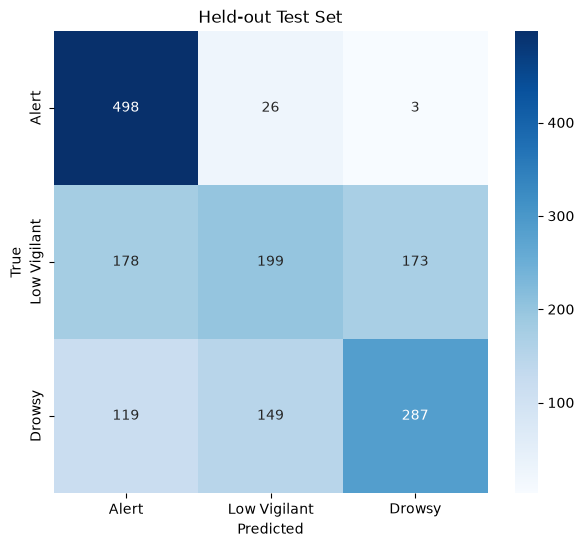

Accuracy: 0.6029411764705882
Macro F1: 0.5826635172643037


In [94]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    yticklabels=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ]
)

plt.title("Held-out Test Set")
plt.ylabel("True")
plt.xlabel("Predicted")

plt.savefig(
    PROJECT_ROOT / "heldout_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Accuracy:",
      accuracy_score(all_labels, all_preds))
print("Macro F1:",
      f1_score(all_labels, all_preds, average="macro"))

In [95]:
from sklearn.metrics import f1_score, accuracy_score

results = []

start = 0

for s in PHASE9_SUBJECTS:
    n = len(test_df[test_df["subject"] == s])

    y_true = np.array(all_labels)[start:start+n]
    y_pred = np.array(all_preds)[start:start+n]

    results.append({
        "Subject": s,
        "Windows": n,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    })

    start += n

pd.DataFrame(results)

,Subject,Windows,Accuracy,Macro_F1
0,01,175,0.634286,0.514547
1,06,140,0.650000,0.553358
2,11,183,0.650273,0.639895
3,16,161,0.428571,0.435719
4,21,174,0.522989,0.479925
5,26,212,0.466981,0.471378
6,31,186,0.553763,0.524674
7,36,180,0.822222,0.819005
8,41,221,0.692308,0.676481


In [96]:
sample = test_df.iloc[0]["embedding_path"]
print(sample)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\normalized_embeddings\01\alert.npy


In [97]:
arr = np.load(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "normalized_embeddings"
    / "01"
    / "alert.npy"
)

print(arr.mean())
print(arr.std())

-6.1231096e-09
0.80921954


In [98]:
for s in PHASE9_SUBJECTS:
    subject_df = test_df[
        test_df["subject"] == s
    ]

    print(
        s,
        len(subject_df),
        subject_df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .to_dict()
    )

01 175 {0: 0.34285714285714286, 1: 0.32571428571428573, 2: 0.3314285714285714}
06 140 {0: 0.42142857142857143, 1: 0.29285714285714287, 2: 0.2857142857142857}
11 183 {0: 0.32786885245901637, 1: 0.3442622950819672, 2: 0.32786885245901637}
16 161 {0: 0.2795031055900621, 1: 0.36024844720496896, 2: 0.36024844720496896}
21 174 {0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}
26 212 {0: 0.2783018867924528, 1: 0.4056603773584906, 2: 0.3160377358490566}
31 186 {0: 0.3548387096774194, 1: 0.3118279569892473, 2: 0.3333333333333333}
36 180 {0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}
41 221 {0: 0.27149321266968324, 1: 0.31221719457013575, 2: 0.416289592760181}


In [99]:
subject_results = []

for s in PHASE9_SUBJECTS:
    mask = (
        test_df["subject"]
        .reset_index(drop=True)
        == s
    )

    idx = np.where(mask)[0]

    y_true = np.array(all_labels)[idx]
    y_pred = np.array(all_preds)[idx]

    subject_results.append({
        "Subject": s,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    })

subject_results = pd.DataFrame(subject_results)
print(subject_results)

  Subject  Accuracy  Macro_F1
0      01  0.634286  0.514547
1      06  0.650000  0.553358
2      11  0.650273  0.639895
3      16  0.428571  0.435719
4      21  0.522989  0.479925
5      26  0.466981  0.471378
6      31  0.553763  0.524674
7      36  0.822222  0.819005
8      41  0.692308  0.676481


In [100]:
for s in ["01", "06", "11", "16", "21"]:
    for state in ["alert", "low_vigilant", "drowsy"]:
        arr = np.load(
            PROJECT_ROOT
            / "processed"
            / "UTA"
            / "normalized_embeddings"
            / s
            / f"{state}.npy"
        )

        print(
            s,
            state,
            f"mean={arr.mean():.4f}",
            f"std={arr.std():.4f}",
            f"min={arr.min():.4f}",
            f"max={arr.max():.4f}"
        )

01 alert mean=-0.0000 std=0.8092 min=-3.3497 max=24.9402
01 low_vigilant mean=0.0548 std=2.8308 min=-4.2040 max=552.7170
01 drowsy mean=0.3845 std=6.2803 min=-4.2040 max=478.5497
06 alert mean=-0.0000 std=0.9103 min=-1.5986 max=24.6780
06 low_vigilant mean=0.0204 std=1.3063 min=-1.5986 max=96.1427
06 drowsy mean=-0.0476 std=0.8643 min=-1.5986 max=35.3149
11 alert mean=-0.0000 std=0.8279 min=-3.0173 max=25.0400
11 low_vigilant mean=2.2423 std=15.5416 min=-3.0173 max=698.7162
11 drowsy mean=0.8744 std=10.0360 min=-3.0173 max=673.9020
16 alert mean=-0.0000 std=0.8740 min=-2.8470 max=21.7486
16 low_vigilant mean=0.7044 std=4.6095 min=-3.4790 max=343.4884
16 drowsy mean=-0.0146 std=2.8470 min=-3.4790 max=234.7362
21 alert mean=0.0000 std=0.8734 min=-3.1161 max=24.5968
21 low_vigilant mean=0.2781 std=6.0681 min=-3.1161 max=526.7753
21 drowsy mean=0.0410 std=2.8245 min=-3.1161 max=378.8427


In [101]:
std = np.load(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "normalized_embeddings"
    / "01"
    / "std.npy"
)

print(std.min())
print(np.percentile(std, [1, 5, 10]))
print((std < 1e-6).sum())
print((std < 1e-4).sum())

0.01
[0.01 0.01 0.01]
0
0


In [102]:
subject = "01"

std = np.load(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "normalized_embeddings"
    / subject
    / "std.npy"
)

print("10 smallest std values:")
print(np.sort(std)[:10])

print("\nIndices of smallest std values:")
print(np.argsort(std)[:10])

10 smallest std values:
[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]

Indices of smallest std values:
[ 68 247 508  18 339  20  25  26 354  29]


In [ ]:
idx = np.argsort(std)[:10]

for state in ["alert", "low_vigilant", "drowsy"]:
    arr = np.load(
        PROJECT_ROOT
        / "processed"
        / "UTA"
        / "normalized_embeddings"
        / subject
        / f"{state}.npy"
    )

    print(f"\n{state}")
    print(arr[:, idx].max(axis=0))


alert
[ 0.        0.        0.       11.540426  0.        0.        0.
  0.        0.       15.178936]

low_vigilant
[ 0.        0.       65.0377   13.430809  0.        0.        0.
  0.        0.       54.529423]

drowsy
[  0.         0.       148.4447    47.440845   0.         0.
   0.         0.         0.        39.176918]


: 